# Simple Evolutionary Exploration  Walkthrough

This notebook contains instructions on how to use the SEE module, along with several examples. These instructions will cover the following parts: 
* [Import Image Files](#Import_Image_Files)
* [Manual Search](#Manual_Search)
* [Genetic Algorithm Search](#Genetic_Algorithm_Search)
* [Reading the Results](#Reading_the_Results)

----
<a name="Import_Image_Files"></a>

## Import Image Files

First import the following packages:

In [ ]:
import random
random.seed(2)

In [2]:
%matplotlib inline
import matplotlib.pylab as plt
import imageio

from see import JupyterGUI

Dropdown(description='Choose image:', options=(PosixPath('Image_data/Examples/AA_Chameleon.jpg'), PosixPath('I…

import imageio
img = imageio.imread('Image_data/Examples/AA_Chameleon.jpg')
gmask = imageio.imread('Image_data/Examples/AA_Chameleon_GT.png')


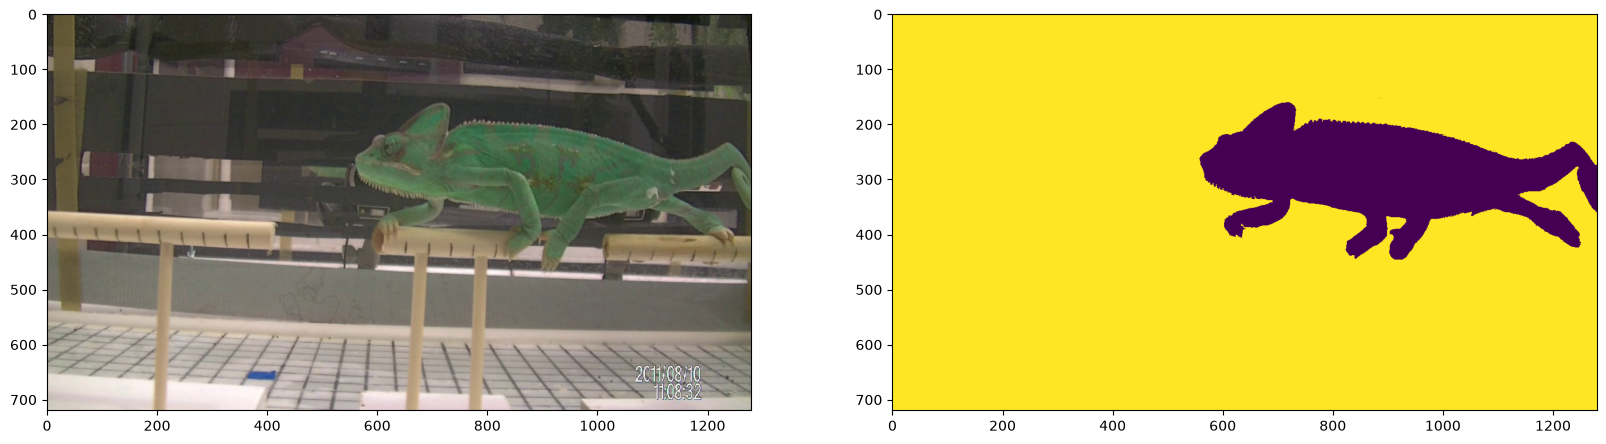

In [3]:
data = JupyterGUI.pickimage()

# Create Workflow

In [4]:
from see import base_classes 

In [5]:
from see.Segmentors import segmentor
from see.ColorSpace import colorspace
from see.Workflow import workflow
from see.Segment_Fitness import segment_fitness

workflow.addalgos([colorspace, segmentor, segment_fitness])
wf = workflow()
print(wf)

<class 'see.Workflow.workflow'> parameters: 
	colorspace = RGB
	multichannel = True
	channel = 2
	algorithm = ColorThreshold
	alpha1 = 0.3
	alpha2 = 0.5
	beta1 = 0.2
	beta2 = 0.7
	gamma1 = 0.3
	gamma2 = 0.5
	n_segments = 2
	max_num_iter = 10



In [6]:
from see.base_classes import pipedata
individual = segmentor()
d = pipedata()
d.append([data.img])
d.gtruth.append(data.gmask)
individual.runAlgo(d)

<class 'see.Segmentors.segmentor'> parameters: 
	algorithm = ColorThreshold
	alpha1 = 0.3
	alpha2 = 0.5
	beta1 = 0.2
	beta2 = 0.7
	gamma1 = 0.3
	gamma2 = 0.5
	n_segments = 2
	max_num_iter = 10

Time: 0.008 s


[[array([[[ 42,  45,  34],
          [ 41,  44,  33],
          [ 41,  44,  33],
          ...,
          [ 37,  39,  25],
          [ 32,  35,  18],
          [ 27,  30,  13]],
  
         [[ 41,  44,  33],
          [ 40,  43,  32],
          [ 40,  43,  32],
          ...,
          [ 36,  38,  24],
          [ 32,  35,  18],
          [ 29,  32,  15]],
  
         [[ 39,  42,  31],
          [ 39,  42,  31],
          [ 39,  42,  31],
          ...,
          [ 35,  37,  23],
          [ 33,  36,  19],
          [ 32,  35,  18]],
  
         ...,
  
         [[210, 206, 194],
          [209, 205, 193],
          [209, 205, 193],
          ...,
          [184, 182, 169],
          [184, 182, 169],
          [183, 181, 168]],
  
         [[209, 205, 193],
          [209, 205, 193],
          [208, 204, 192],
          ...,
          [183, 181, 168],
          [183, 181, 168],
          [183, 181, 168]],
  
         [[208, 204, 192],
          [208, 204, 192],
          [208, 204, 192

----
<a name="Genetic_Algorithm_Search"></a>

## Genetic Algorithm Search

First import image files, as well as the following packages:

In [7]:
from see import GeneticSearch

To run the genetic algorithm, we need to initialize an instance of an evolver. The original image and ground truth segmentation image are inputs to it, along with an integer value for population size. This value sets how many indivudals are in our population. For this example, we'll set this number to be equal to 10.

In [8]:
mydata = base_classes.pipedata()
mydata.append([data.img])
mydata.gtruth.append(data.gmask)

In [9]:
my_evolver = GeneticSearch.Evolver(workflow, mydata, pop_size=10)

Now that the evolver has been initialized, we can run the genetic algorithm for a specified number of generations (or iterations). Here we will set this number equal to 5.

In [10]:
# warnings may appear when this runs
population = my_evolver.run(ngen=2)

Initializing a new random population
Generation 0/2 of population size 10
<class 'see.Workflow.workflow'> parameters: 
	colorspace = RGB
	multichannel = True
	channel = 0
	algorithm = Watershed
	alpha1 = 0.3359375
	alpha2 = 0.61328125
	beta1 = 0.5
	beta2 = 0.421875
	gamma1 = 0.0703125
	gamma2 = 0.31640625
	n_segments = 6
	max_num_iter = 13

Time: 4.302 s
p_fitness=1.000000347200389

<class 'see.Workflow.workflow'> parameters: 
	colorspace = YDbDr
	multichannel = False
	channel = 2
	algorithm = Morphological_Chan_Vese
	alpha1 = 0.53515625
	alpha2 = 0.0703125
	beta1 = 0.0546875
	beta2 = 0.7265625
	gamma1 = 0.9296875
	gamma2 = 0.63671875
	n_segments = 6
	max_num_iter = 14

Time: 1.519 s
p_fitness=1.5

<class 'see.Workflow.workflow'> parameters: 
	colorspace = YDbDr
	multichannel = True
	channel = 2
	algorithm = Slic
	alpha1 = 0.46875
	alpha2 = 0.4609375
	beta1 = 0.046875
	beta2 = 0.3515625
	gamma1 = 0.6484375
	gamma2 = 0.34375
	n_segments = 2
	max_num_iter = 17

Time: 1.021 s
p_fitness=1.

----
<a name="Reading_the_Results"></a>

## Reading the Results

After the genetic algorithm is complete, we can retrieve the individuals that resulted in the lowest (best) fitness values by printing `my_evolver.hof`. These individuals are sorted according to fitness value, so to get the overal best individual, we can simply look at the first individual in the list. 

In [11]:
params = my_evolver.hof[0]

print('Best Individual:\n', params)

Best Individual:
 ['YDbDr', False, 1, 'SlicO', 0.6484375, 0.33203125, 0.53515625, 0.95703125, 0.0703125, 0.31640625, 8, 13]


We can see the mask this individual generates by evaluating it, then plotting the result:

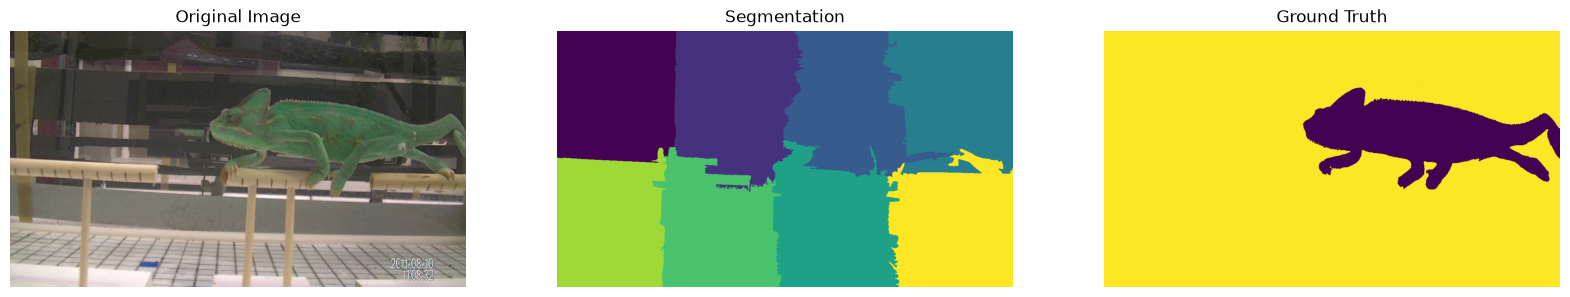

In [12]:
seg = workflow(params)
mydata = seg.pipe(mydata)

plt.figure(figsize=(20, 10))
plt.subplot(131)
plt.imshow(mydata[0][0])
plt.title("Original Image")
plt.axis('off')

plt.subplot(132)
plt.imshow(mydata[0][-1])
plt.title("Segmentation")
plt.axis('off')

plt.subplot(133)
plt.imshow(mydata.gtruth[0])
plt.title("Ground Truth")
plt.axis('off')

plt.tight_layout
plt.show()

We can also use `FitnessFunction` to calculate the final fitness value for this algorithm:

In [13]:
print('Fitness Value: ', mydata.fitness)

Fitness Value:  0.8736842896318561


If this value is satisfactory, we can then get usable code to run this algorithm anywhere, including outside this notebook. The `print_best_algorithm_code` function does this using the given individual:

In [14]:
dir(base_classes)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'algorithm',
 'copy',
 'inspect',
 'mutateAlgo',
 'param_space',
 'pipedata',
 'popCounts',
 'random',
 'time']

In [15]:
ex = base_classes.print_best_algorithm_code(my_evolver.hof[0])

AttributeError: module 'see.base_classes' has no attribute 'print_best_algorithm_code'

With this code, make sure to import skimage, along with any input images this algorithm will be applied to.